In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import re
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Hiển thị biểu đồ trên Colab/Kaggle/Jupyter
%matplotlib inline

In [5]:
# 1. Đường dẫn file (Bạn có thể điều chỉnh lại nếu chạy trên Kaggle/môi trường khác)
train_path = '/content/drive/MyDrive/Colab Notebooks/cs114/Data/train_clean.parquet'
val_path = '/content/drive/MyDrive/Colab Notebooks/cs114/Data/val_clean.parquet'
test_path = '/content/drive/MyDrive/Colab Notebooks/cs114/Data/test_clean.parquet'

# 2. Đọc dữ liệu
train_df = pd.read_parquet(train_path)
val_df = pd.read_parquet(val_path)
test_df = pd.read_parquet(test_path)

# 3. Label Mapping thành 8 class chuẩn
label_mapping = {
    'business': 'business_finance', 'money': 'business_finance',
    'world': 'world_environment', 'environment': 'world_environment',
    'culture': 'culture_lifestyle', 'fashion': 'culture_lifestyle',
    'technology': 'tech_science_games', 'science': 'tech_science_games', 'games': 'tech_science_games',
    'sport': 'sport', 'film': 'film', 'music': 'music', 'food': 'food'
}

for df in [train_df, val_df, test_df]:
    df['label'] = df['label'].map(label_mapping).fillna(df['label'])
    df['text'] = df['title'].astype(str) + " " + df['article'].astype(str)

# 4. Encode Label
label_encoder = LabelEncoder()
train_df['label_id'] = label_encoder.fit_transform(train_df['label'])
val_df['label_id'] = label_encoder.transform(val_df['label'])
test_df['label_id'] = label_encoder.transform(test_df['label'])

print(f"Số lượng classes: {len(label_encoder.classes_)}")
print(f"Danh sách các lớp: {label_encoder.classes_}")

Số lượng classes: 8
Danh sách các lớp: ['business_finance' 'culture_lifestyle' 'film' 'food' 'music' 'sport'
 'tech_science_games' 'world_environment']


In [6]:
# Giới hạn vocab_size ở mức 30000 giúp giảm overfitting và tiết kiệm memory
MAX_VOCAB_SIZE = 30000
MAX_SEQ_LENGTH = 512

def get_tokens(text):
    return re.findall(r'\b\w+\b', str(text).lower())

# 1. Tạo Vocabulary từ tập train
word_counts = Counter()
for text in train_df['text']:
    word_counts.update(get_tokens(text))

top_words = word_counts.most_common(MAX_VOCAB_SIZE)
word2idx = {'<PAD>': 0, '<UNK>': 1}
for idx, (word, _) in enumerate(top_words, start=2):
    word2idx[word] = idx

# 2. Hàm chuyển đổi Text -> List Indices (Đã padding)
def text_to_indices(text, word2idx, max_len):
    tokens = get_tokens(text)
    indices = [word2idx.get(w, word2idx['<UNK>']) for w in tokens]
    if len(indices) < max_len:
        indices = indices + [word2idx['<PAD>']] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

print("Đang pre-process text sang dạng tensor...")
train_df['indices'] = train_df['text'].apply(lambda x: text_to_indices(x, word2idx, MAX_SEQ_LENGTH))
val_df['indices'] = val_df['text'].apply(lambda x: text_to_indices(x, word2idx, MAX_SEQ_LENGTH))
test_df['indices'] = test_df['text'].apply(lambda x: text_to_indices(x, word2idx, MAX_SEQ_LENGTH))
print("Hoàn tất!")

Đang pre-process text sang dạng tensor...
Hoàn tất!


In [7]:
# FastTextDataset và DataLoader
class TextDataset(Dataset):
    def __init__(self, indices_list, labels):
        self.indices = torch.tensor(indices_list.tolist(), dtype=torch.long)
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.indices[idx], self.labels[idx]

# Batch size = 64 phù hợp với giới hạn VRAM 4GB
BATCH_SIZE = 64

train_dataset = TextDataset(train_df['indices'], train_df['label_id'])
val_dataset = TextDataset(val_df['indices'], val_df['label_id'])
test_dataset = TextDataset(test_df['indices'], test_df['label_id'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
import torch.nn.functional as F

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout_rate):
        super(BiLSTMClassifier, self).__init__()

        # Layer nhúng từ vựng
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Bidirectional LSTM (Cố định 1 lớp)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout_rate)
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # x shape: [batch_size, seq_length]
        embedded = self.embedding(x) # [batch_size, seq_length, embed_dim]

        # Trích xuất đầu ra từ LSTM
        # lstm_out shape chứa tất cả các hidden states ở MỌI bước thời gian:
        # [batch_size, seq_length, hidden_dim * 2]
        lstm_out, _ = self.lstm(embedded)

        # SỬ DỤNG GLOBAL MAX POOLING thay vì lấy hidden state cuối cùng
        # Điều này giúp lấy được tín hiệu mạnh nhất (từ khóa quan trọng) trên toàn bộ chuỗi 500 từ
        # pooled_out shape: [batch_size, hidden_dim * 2]
        pooled_out, _ = torch.max(lstm_out, dim=1)

        # Đưa qua Dropout và Fully connected layer
        out = self.fc(self.dropout(pooled_out))
        return out

In [9]:
def format_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

# --- Hyperparameters ---
EMBED_DIM = 100
HIDDEN_DIM = 128
#NUM_LAYERS = 2
NUM_CLASSES = len(label_encoder.classes_)
DROPOUT_RATE = 0.5
LEARNING_RATE = 2e-4
EPOCHS = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang train trên thiết bị: {device}")

vocab_size_real = len(word2idx)
model = BiLSTMClassifier(
    vocab_size_real,
    EMBED_DIM,
    HIDDEN_DIM,
    NUM_CLASSES,
    #NUM_LAYERS,
    DROPOUT_RATE
).to(device)

criterion = nn.CrossEntropyLoss()
# Trình tối ưu AdamW đi kèm weight_decay để tăng khả năng phạt chống overfitting
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

train_losses, val_losses, train_f1s, val_f1s = [], [], [], []
best_val_f1 = 0.0

Đang train trên thiết bị: cuda


In [10]:
print("Bắt đầu quá trình training BiLSTM...")
total_start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    # --- TRAINING ---
    model.train()
    total_loss = 0
    all_train_preds, all_train_labels = [], []

    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_loss = total_loss / len(train_loader)
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    with torch.no_grad():
        for val_texts, val_labels in val_loader:
            val_texts, val_labels = val_texts.to(device), val_labels.to(device)
            val_outputs = model(val_texts)
            loss = criterion(val_outputs, val_labels)

            val_loss += loss.item()
            val_preds = torch.argmax(val_outputs, dim=1)

            all_val_preds.extend(val_preds.cpu().numpy())
            all_val_labels.extend(val_labels.cpu().numpy())

    val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    epoch_end_time = time.time()
    epoch_mins, epoch_secs = format_time(epoch_start_time, epoch_end_time)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Thời gian: {epoch_mins}m {epoch_secs}s")
    print(f"\tTrain Loss: {train_loss:.4f} - F1 Macro: {train_f1:.4f}")
    print(f"\tVal Loss:   {val_loss:.4f} - F1 Macro: {val_f1:.4f}")

    # Chốt best model bằng F1 Macro trên validation
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'bilstm_best_model.pth')

total_end_time = time.time()
total_mins, total_secs = format_time(total_start_time, total_end_time)

model.load_state_dict(torch.load('bilstm_best_model.pth'))

print("-" * 50)
print(f"Training xong! Tổng thời gian huấn luyện: {total_mins} phút {total_secs} giây.")
print(f"Best Validation F1 Macro: {best_val_f1:.4f}")

Bắt đầu quá trình training BiLSTM...
Epoch 01/10 | Thời gian: 0m 13s
	Train Loss: 2.0022 - F1 Macro: 0.1840
	Val Loss:   1.8599 - F1 Macro: 0.4078
Epoch 02/10 | Thời gian: 0m 12s
	Train Loss: 1.7079 - F1 Macro: 0.4386
	Val Loss:   1.4811 - F1 Macro: 0.6074
Epoch 03/10 | Thời gian: 0m 12s
	Train Loss: 1.3186 - F1 Macro: 0.5825
	Val Loss:   1.1255 - F1 Macro: 0.6541
Epoch 04/10 | Thời gian: 0m 12s
	Train Loss: 1.1089 - F1 Macro: 0.6409
	Val Loss:   0.9953 - F1 Macro: 0.7046
Epoch 05/10 | Thời gian: 0m 13s
	Train Loss: 0.9622 - F1 Macro: 0.6931
	Val Loss:   0.8554 - F1 Macro: 0.7411
Epoch 06/10 | Thời gian: 0m 13s
	Train Loss: 0.8504 - F1 Macro: 0.7289
	Val Loss:   0.7619 - F1 Macro: 0.7844
Epoch 07/10 | Thời gian: 0m 13s
	Train Loss: 0.7625 - F1 Macro: 0.7562
	Val Loss:   0.6903 - F1 Macro: 0.7936
Epoch 08/10 | Thời gian: 0m 13s
	Train Loss: 0.6969 - F1 Macro: 0.7761
	Val Loss:   0.6425 - F1 Macro: 0.8098
Epoch 09/10 | Thời gian: 0m 13s
	Train Loss: 0.6382 - F1 Macro: 0.7945
	Val Loss:  

In [11]:
print("="*55)
print("ĐO THỜI GIAN INFERENCE (AVG INFERENCE LATENCY)")
print("="*55)

# Đảm bảo mô hình đang ở chế độ đánh giá
model.eval()

# Bắt đầu đo thời gian
start_time = time.time()

# Tiến hành dự đoán trên toàn bộ tập test
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        # Chỉ đo thời gian model dự đoán
        outputs = model(texts)
        preds = torch.argmax(outputs, dim=1)

# Kết thúc đo thời gian
end_time = time.time()

# Tính toán các thông số
total_inference_time = end_time - start_time
num_samples = len(test_loader.dataset) # Tổng số văn bản
num_batches = len(test_loader)         # Tổng số batch

avg_latency_per_sample = total_inference_time / num_samples
avg_latency_per_batch = total_inference_time / num_batches

print(f"Tổng thời gian dự đoán trên tập test: {total_inference_time:.4f} giây")
print(f"Tổng số văn bản (samples): {num_samples}")
print(f"Tổng số lô (batches): {num_batches} (Batch size = {test_loader.batch_size})")
print("-" * 55)
print(f"Avg Inference Latency (per batch):  {avg_latency_per_batch * 1000:.4f} ms")
print(f"Avg Inference Latency (per sample): {avg_latency_per_sample * 1000:.4f} ms")
print("="*55)

ĐO THỜI GIAN INFERENCE (AVG INFERENCE LATENCY)
Tổng thời gian dự đoán trên tập test: 0.9121 giây
Tổng số văn bản (samples): 5837
Tổng số lô (batches): 92 (Batch size = 64)
-------------------------------------------------------
Avg Inference Latency (per batch):  9.9139 ms
Avg Inference Latency (per sample): 0.1563 ms


BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) TẬP TEST
                    precision    recall  f1-score   support

  business_finance       0.81      0.83      0.82       625
 culture_lifestyle       0.72      0.73      0.72       878
              film       0.87      0.88      0.87       879
              food       0.96      0.91      0.93       564
             music       0.83      0.88      0.86       770
             sport       0.94      0.97      0.96       792
tech_science_games       0.81      0.66      0.73       617
 world_environment       0.77      0.80      0.79       712

          accuracy                           0.84      5837
         macro avg       0.84      0.83      0.84      5837
      weighted avg       0.84      0.84      0.83      5837

CHI TIẾT ĐỘ ĐO MACRO VÀ WEIGHTED (PRECISION, RECALL, F1)
Macro Precision:    0.8394
Macro Recall:       0.8339
Macro F1-score:     0.8354
------------------------------
Weighted Precision: 0.8360
Weighted Recall:    0.8355
Wei

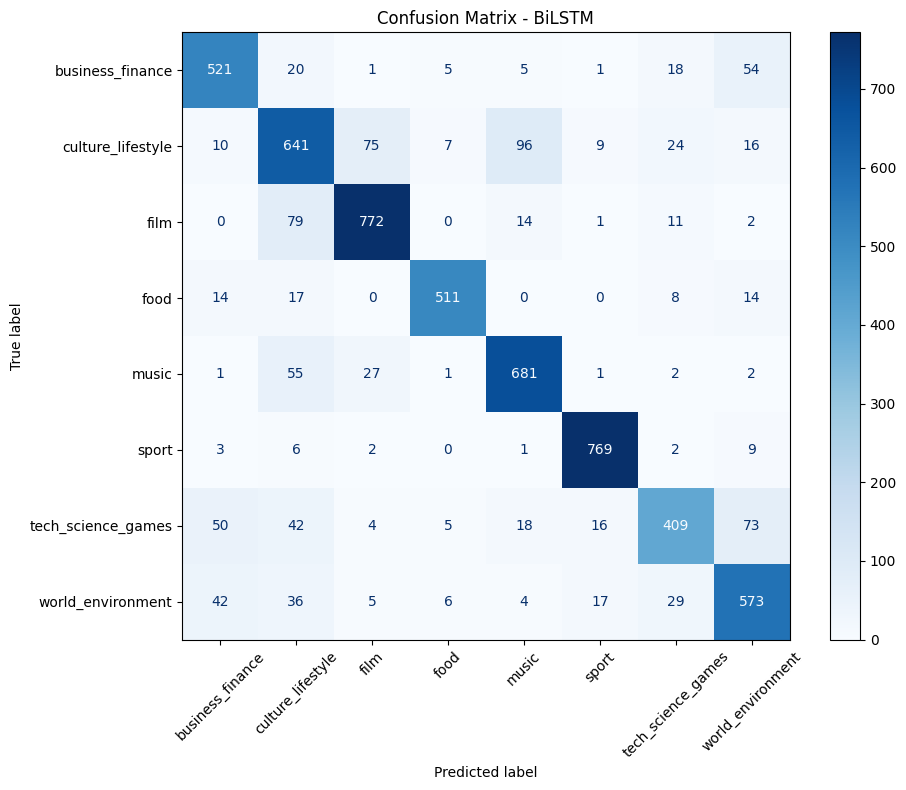

In [12]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for texts, labels in test_loader:
        texts, labels = texts.to(device), labels.to(device)
        outputs = model(texts)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = label_encoder.classes_

macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

weighted_precision = precision_score(all_labels, all_preds, average='weighted')
weighted_recall = recall_score(all_labels, all_preds, average='weighted')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print("="*55)
print("BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) TẬP TEST")
print("="*55)
print(classification_report(all_labels, all_preds, target_names=target_names))

print("="*55)
print("CHI TIẾT ĐỘ ĐO MACRO VÀ WEIGHTED (PRECISION, RECALL, F1)")
print("="*55)
print(f"Macro Precision:    {macro_precision:.4f}")
print(f"Macro Recall:       {macro_recall:.4f}")
print(f"Macro F1-score:     {macro_f1:.4f}")
print("-" * 30)
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1-score:  {weighted_f1:.4f}")
print("="*55)

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix - BiLSTM')
plt.tight_layout()
plt.show()

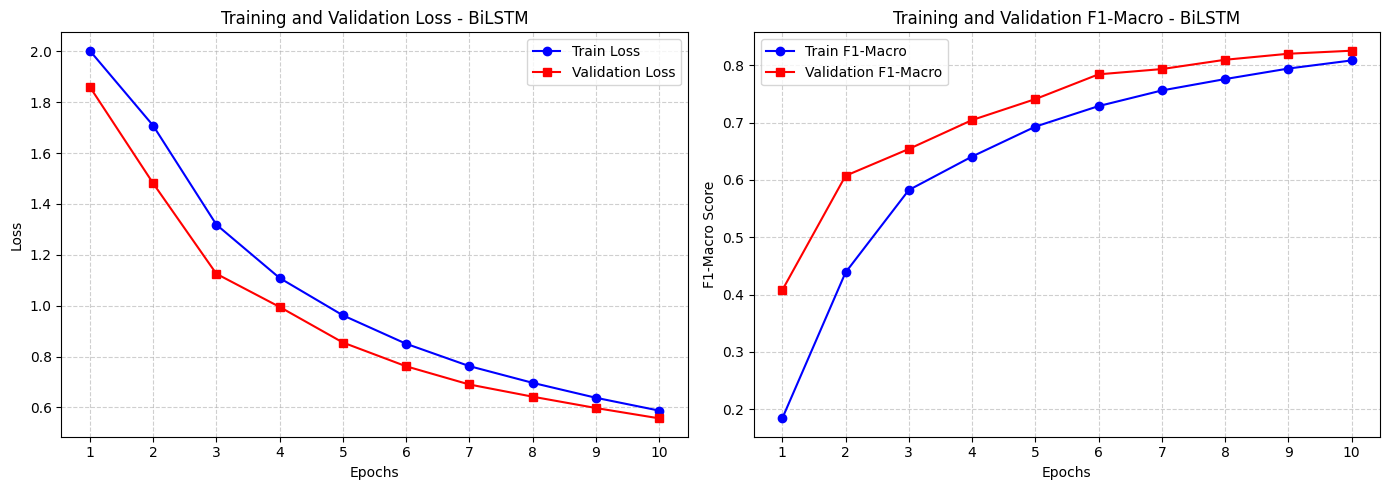

In [13]:
# Loss & F1-macro curve
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

# 1. Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', marker='s')
plt.title('Training and Validation Loss - BiLSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Biểu đồ F1-Macro
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_f1s, label='Train F1-Macro', color='blue', marker='o')
plt.plot(epochs_range, val_f1s, label='Validation F1-Macro', color='red', marker='s')
plt.title('Training and Validation F1-Macro - BiLSTM')
plt.xlabel('Epochs')
plt.ylabel('F1-Macro Score')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [14]:
save_dir = '/content/drive/MyDrive/Colab Notebooks/cs114/Model/BiLSTM'
os.makedirs(save_dir, exist_ok=True)

# Save BiLSTM Weights
torch.save(model.state_dict(), os.path.join(save_dir, 'bilstm_weights.pth'))
# Save Word2Idx
with open(os.path.join(save_dir, 'word2idx.pkl'), 'wb') as f:
    pickle.dump(word2idx, f)
# Save Label Encoder
with open(os.path.join(save_dir, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"Đã lưu model BiLSTM và các file cấu hình thành công tại {save_dir}")

Đã lưu model BiLSTM và các file cấu hình thành công tại /content/drive/MyDrive/Colab Notebooks/cs114/Model/BiLSTM
